In [5]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

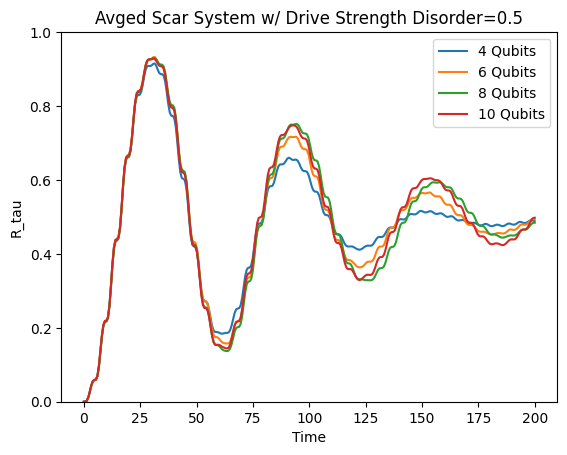

In [6]:
wd = 0.642570281124498
tlist = np.linspace(0, 200, 300)
nlist = np.linspace(4, 10, 4)
d = 0.5
reals = 100

Rtau_plot = []
for n in nlist:
    N = int(n)
    Rtau_scar = np.zeros(len(tlist))
    for _ in range(reals):
        H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, random_seed=True, ds_detuning=d, random_drive_strength=True)
        args = {"A": 0.1, "omega": wd}
        H = qt.QobjEvo([H0, [H1, coeff]], args=args)
        psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
        Rtau = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0]))
        Rtau_scar += Rtau
    Rtau_plot.append(Rtau_scar / reals)

plt.title(f"Avged Scar System w/ Drive Strength Disorder={d}")
plt.ylabel("R_tau")
plt.xlabel("Time")
plt.ylim(0, 1)
for i in range(len(Rtau_plot)):
    plt.plot(tlist, Rtau_plot[i], label=f"{int(nlist[i])} Qubits")
plt.legend()
plt.show()